In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/gosai/k562_gosai_ref_alt.csv.gz", compression="gzip")
df.head(2)

,offset_-90,offset_-80,offset_-60,offset_-40,offset_-20,offset_0,offset_20,offset_40,offset_60,offset_80,offset_90
0,"{'ref': -0.23091280460357666, 'alt': -0.212736...","{'ref': -0.13728174567222595, 'alt': -0.118596...","{'ref': -0.34897565841674805, 'alt': -0.315950...","{'ref': -0.014817245304584503, 'alt': 0.025857...","{'ref': -0.18735051155090332, 'alt': -0.141441...","{'ref': -0.22515085339546204, 'alt': -0.167120...","{'ref': -0.4655846357345581, 'alt': -0.4303688...","{'ref': -0.5477486252784729, 'alt': -0.5224207...","{'ref': -0.6999592185020447, 'alt': -0.6817108...","{'ref': -0.5176305770874023, 'alt': -0.4858403...","{'ref': -0.48435068130493164, 'alt': -0.475452..."
1,"{'ref': -0.629867672920227, 'alt': -0.39773607...","{'ref': 0.08561490476131439, 'alt': 0.23752069...","{'ref': 1.0494202375411987, 'alt': 1.225171089...","{'ref': 0.6721367239952087, 'alt': 0.673731505...","{'ref': -0.03369162976741791, 'alt': -0.081096...","{'ref': -0.09581919759511948, 'alt': -0.145064...","{'ref': 0.06069188565015793, 'alt': 0.02839676...","{'ref': -0.16009053587913513, 'alt': -0.204932...","{'ref': -0.20780077576637268, 'alt': -0.230620...","{'ref': -0.22241300344467163, 'alt': -0.183650...","{'ref': -0.26854705810546875, 'alt': -0.160904..."


In [3]:
def flip_offset(col_name):
    if col_name.startswith("offset_"):
        val = int(col_name.split("_")[1])
        return f"offset_{-val}"
    else:
        return col_name

df = df.rename(columns=flip_offset)

# Extract offset columns, sort them by numeric value
offset_cols = [c for c in df.columns if c.startswith("offset_")]
sorted_offsets = sorted(offset_cols, key=lambda x: int(x.split("_")[1]))

# Reorder dataframe columns: sorted offsets first, then any others
other_cols = [c for c in df.columns if c not in offset_cols]
df = df[sorted_offsets + other_cols]

print(df.head(2))

                                          offset_-90  \
0  {'ref': -0.48435068130493164, 'alt': -0.475452...   
1  {'ref': -0.26854705810546875, 'alt': -0.160904...   

                                          offset_-80  \
0  {'ref': -0.5176305770874023, 'alt': -0.4858403...   
1  {'ref': -0.22241300344467163, 'alt': -0.183650...   

                                          offset_-60  \
0  {'ref': -0.6999592185020447, 'alt': -0.6817108...   
1  {'ref': -0.20780077576637268, 'alt': -0.230620...   

                                          offset_-40  \
0  {'ref': -0.5477486252784729, 'alt': -0.5224207...   
1  {'ref': -0.16009053587913513, 'alt': -0.204932...   

                                          offset_-20  \
0  {'ref': -0.4655846357345581, 'alt': -0.4303688...   
1  {'ref': 0.06069188565015793, 'alt': 0.02839676...   

                                            offset_0  \
0  {'ref': -0.22515085339546204, 'alt': -0.167120...   
1  {'ref': -0.09581919759511948, 'alt': -0.

       offset allele     value
0  offset_-90    ref  1.849791
1  offset_-90    ref  2.579974
2  offset_-90    ref  1.839394


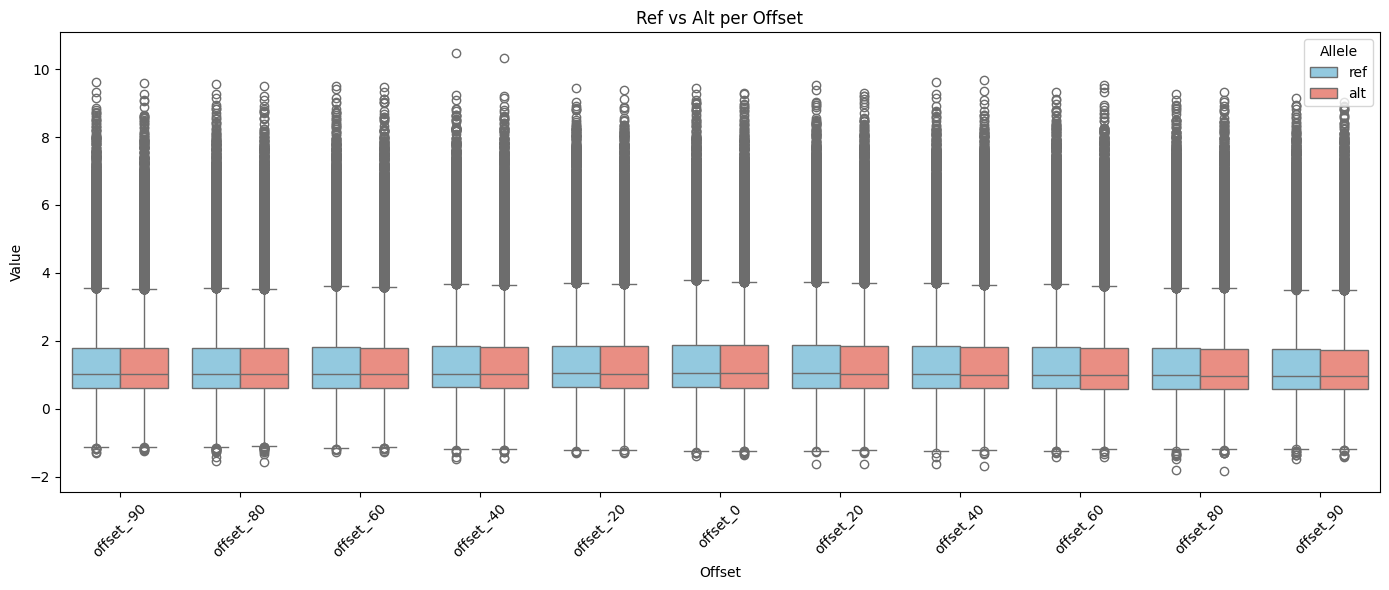

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

long_data = []
for col in df.columns:
    for idx, val in enumerate(df[col]):
        val_dict = ast.literal_eval(val)
        long_data.append({
            "offset": col,
            "ref": val_dict["ref"],
            "alt": val_dict["alt"]
        })

long_df = pd.DataFrame(long_data)

filtered_long_df = long_df[
    (long_df["ref"].abs() > 0.5) | (long_df["alt"].abs() > 0.5)
]

melted_df = filtered_long_df.melt(id_vars="offset", value_vars=["ref", "alt"], 
                         var_name="allele", value_name="value")

# 3. Plot boxplot
plt.figure(figsize=(14,6))
print(melted_df.head(3))
sns.boxplot(data=melted_df, x="offset", y="value", hue="allele",
            palette={"ref":"skyblue", "alt":"salmon"})
plt.xticks(rotation=45)
plt.xlabel("Offset")
plt.ylabel("Value")
plt.title("Ref vs Alt per Offset")
plt.legend(title="Allele")
plt.tight_layout()
plt.show()


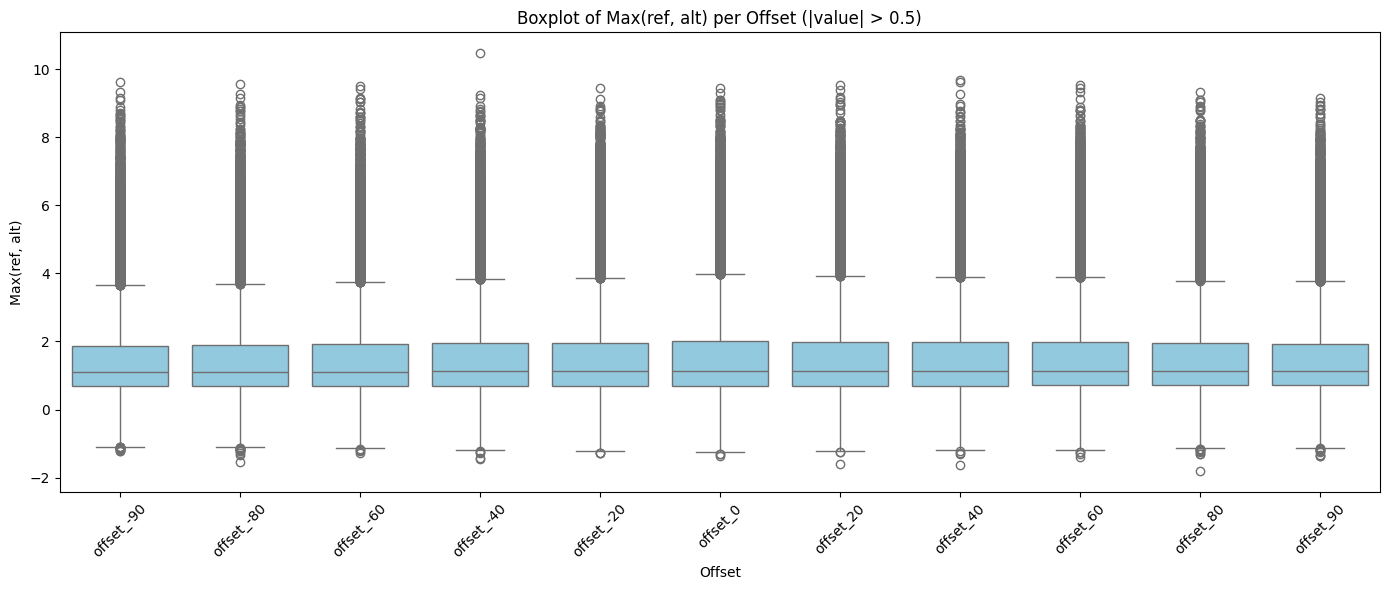

In [5]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert stringified dicts to actual dicts and take max(ref, alt)
max_data = []
for col in df.columns:
    max_col_values = []
    for val in df[col]:
        val_dict = ast.literal_eval(val)
        max_val = max(val_dict["ref"], val_dict["alt"])
        max_col_values.append(max_val)
    max_data.append(max_col_values)

# 2. Create a new dataframe with max values
max_df = pd.DataFrame({col: max_data[i] for i, col in enumerate(df.columns)})

# 3. Melt into long format for seaborn
melted_max_df = max_df.melt(var_name="offset", value_name="max_value")

# ✅ 4. Filter: keep only rows where |max_value| > 0.5
filtered_melted_max_df = melted_max_df[melted_max_df["max_value"].abs() > 0.5]

# 5. Plot boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=filtered_melted_max_df, x="offset", y="max_value", color="skyblue")
plt.xticks(rotation=45)
plt.xlabel("Offset")
plt.ylabel("Max(ref, alt)")
plt.title("Boxplot of Max(ref, alt) per Offset (|value| > 0.5)")
plt.tight_layout()
plt.show()


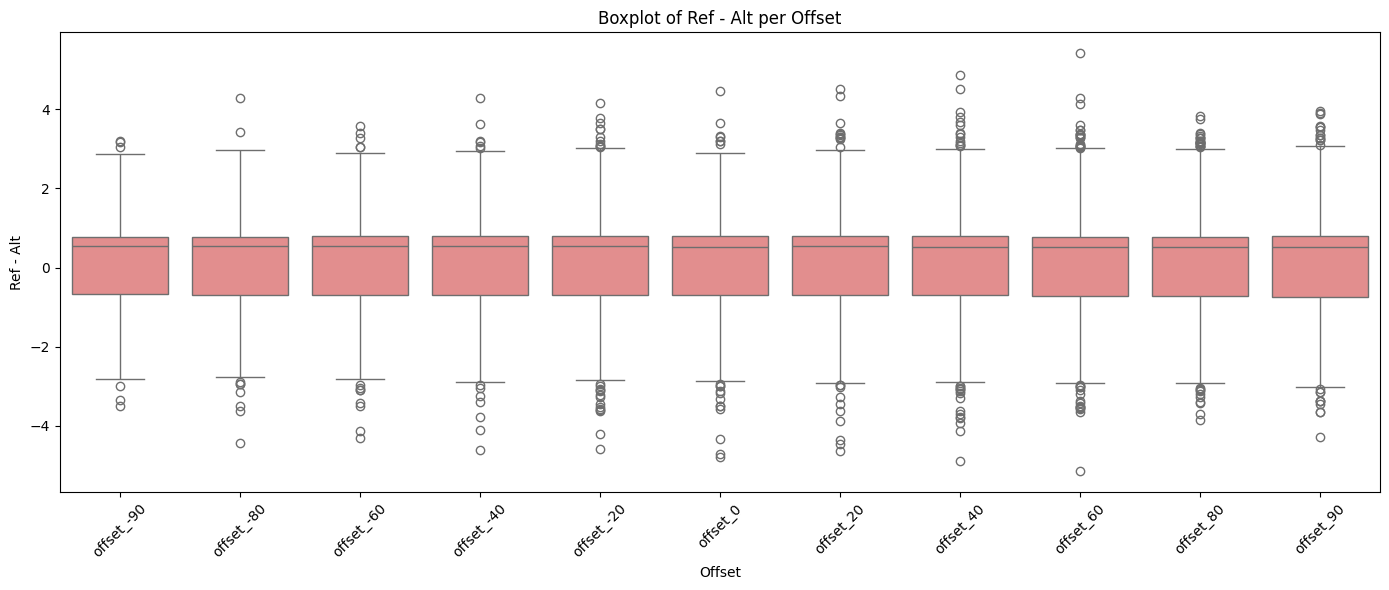

In [6]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your dataframe with stringified dicts

# 1. Convert stringified dicts to dicts and compute ref - alt
diff_data = []
for col in df.columns:
    diff_col_values = []
    for val in df[col]:
        val_dict = ast.literal_eval(val)
        diff_val = val_dict["ref"] - val_dict["alt"]
        diff_col_values.append(diff_val)
    diff_data.append(diff_col_values)

# 2. Create a new dataframe with ref-alt values
diff_df = pd.DataFrame({col: diff_data[i] for i, col in enumerate(df.columns)})

# 3. Melt into long format for seaborn
melted_diff_df = diff_df.melt(var_name="offset", value_name="ref_minus_alt")

filtered_melted_max_df = melted_diff_df[melted_diff_df["ref_minus_alt"].abs() > 0.5]


# 4. Plot boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=filtered_melted_max_df, x="offset", y="ref_minus_alt", color="lightcoral")
plt.xticks(rotation=45)
plt.xlabel("Offset")
plt.ylabel("Ref - Alt")
plt.title("Boxplot of Ref - Alt per Offset")
plt.tight_layout()
plt.show()


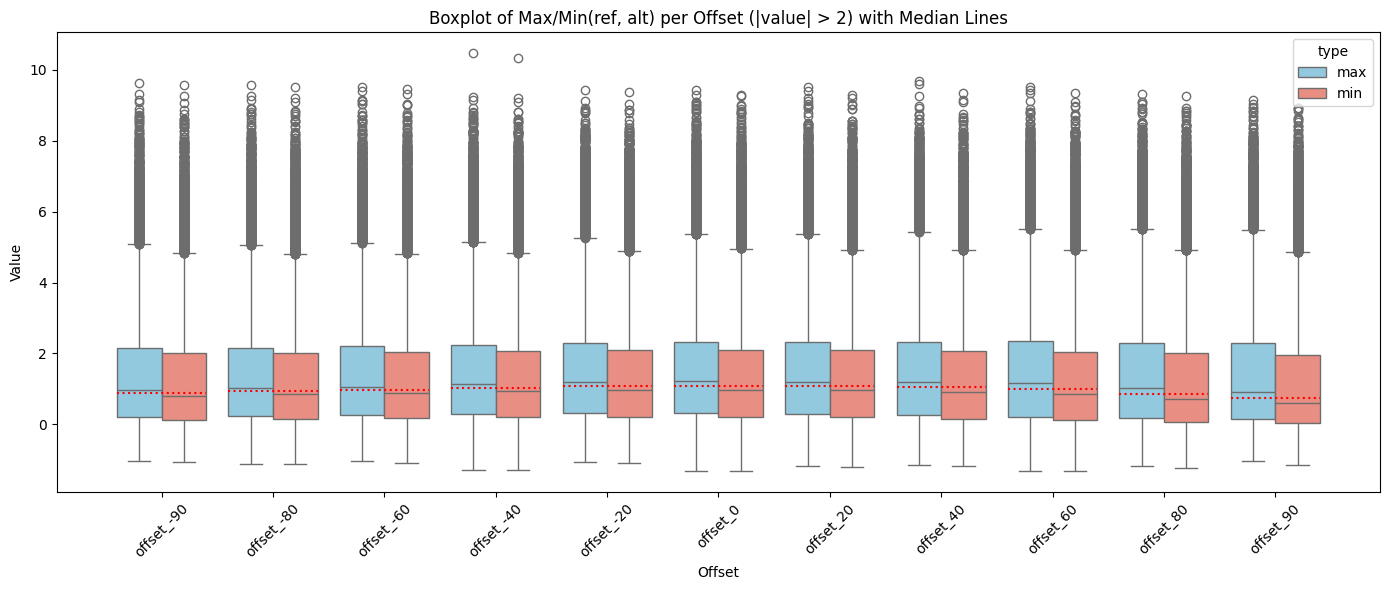

In [13]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

threshold = 2  # filter threshold
filtered_rows = []
# 0️⃣ Filter df: keep only rows where abs(ref) or abs(alt) > threshold

for idx, row in df.iterrows():
    keep_row = False
    for val in row:
        val_dict = ast.literal_eval(val)
        ref, alt = val_dict["ref"], val_dict["alt"]
        if abs(ref) > threshold or abs(alt) > threshold:
            keep_row = True
            break
    if keep_row:
        filtered_rows.append(row)

# Make filtered DataFrame
filtered_df = pd.DataFrame(filtered_rows)

# 1️⃣ Compute max and min for each ref/alt pair (after filtering)
max_data, min_data = [], []
for col in filtered_df.columns:
    max_col_values, min_col_values = [], []
    for val in filtered_df[col]:
        val_dict = ast.literal_eval(val)
        ref, alt = val_dict["ref"], val_dict["alt"]
        max_col_values.append(max(ref, alt))
        min_col_values.append(min(ref, alt))
    max_data.append(max_col_values)
    min_data.append(min_col_values)

# 2️⃣ Create DataFrames
max_df = pd.DataFrame({col: max_data[i] for i, col in enumerate(filtered_df.columns)})
min_df = pd.DataFrame({col: min_data[i] for i, col in enumerate(filtered_df.columns)})

# 3️⃣ Melt both + label
melted_max = max_df.melt(var_name="offset", value_name="value")
melted_max["type"] = "max"

melted_min = min_df.melt(var_name="offset", value_name="value")
melted_min["type"] = "min"

# 4️⃣ Combine
melted_both = pd.concat([melted_max, melted_min])

# 5️⃣ Compute medians (using all values, not filtered)
median_values = pd.concat([max_df, min_df]).median()

# 6️⃣ Plot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=melted_both,
    x="offset",
    y="value",
    hue="type",
    palette={"max": "skyblue", "min": "salmon"}
)

# 7️⃣ Add red dotted median lines for each offset
for i, offset in enumerate(filtered_df.columns):
    median_val = median_values[offset]
    plt.hlines(
        y=median_val,
        xmin=i - 0.4,
        xmax=i + 0.4,
        colors="red",
        linestyles="dotted",
        linewidth=1.5
    )

plt.xticks(rotation=45)
plt.xlabel("Offset")
plt.ylabel("Value")
plt.title(f"Boxplot of Max/Min(ref, alt) per Offset (|value| > {threshold}) with Median Lines")
plt.tight_layout()
plt.show()


       offset     value type
0  offset_-90 -0.475453  max
1  offset_-90 -0.160904  max
2  offset_-90  1.958519  max


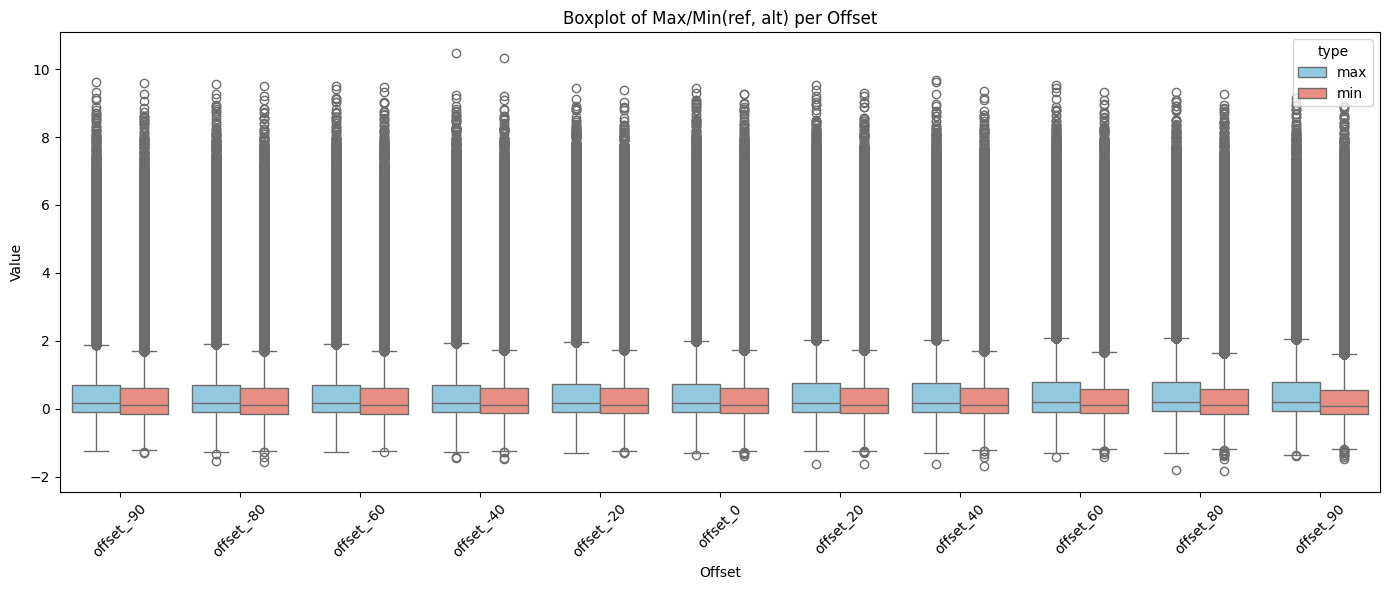

In [4]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

# Compute max and min for each ref/alt pair
max_data, min_data = [], []

for col in df.columns:
    max_col_values, min_col_values = [], []
    for val in df[col]:
        val_dict = ast.literal_eval(val)
        ref, alt = val_dict["ref"], val_dict["alt"]
        max_col_values.append(max(ref, alt))
        min_col_values.append(min(ref, alt))
    max_data.append(max_col_values)
    min_data.append(min_col_values)

# Create DataFrames
max_df = pd.DataFrame({col: max_data[i] for i, col in enumerate(df.columns)})
min_df = pd.DataFrame({col: min_data[i] for i, col in enumerate(df.columns)})

# 3Melt both + label
melted_max = max_df.melt(var_name="offset", value_name="value")
melted_max["type"] = "max"

melted_min = min_df.melt(var_name="offset", value_name="value")
melted_min["type"] = "min"

melted_both = pd.concat([melted_max, melted_min])

median_values = pd.concat([max_df, min_df]).median()


print(melted_both.head(3))
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=melted_both,
    x="offset",
    y="value",
    hue="type",
    palette={"max": "skyblue", "min": "salmon"}
)


plt.xticks(rotation=45)
plt.xlabel("Offset")
plt.ylabel("Value")
plt.title("Boxplot of Max/Min(ref, alt) per Offset")
plt.tight_layout()
plt.show()


In [5]:
min_df

,offset_-90,offset_-80,offset_-60,offset_-40,offset_-20,offset_0,offset_20,offset_40,offset_60,offset_80,offset_90
0,-0.484351,-0.517631,-0.699959,-0.547749,-0.465585,-0.225151,-0.187351,-0.014817,-0.348976,-0.137282,-0.230913
1,-0.268547,-0.222413,-0.230621,-0.204933,0.028397,-0.145064,-0.081096,0.672137,1.049420,0.085615,-0.629868
2,1.849791,2.110400,2.274136,2.514212,2.508146,3.395212,3.260914,1.714140,-0.789862,-0.096931,-0.115842
3,-0.056665,-0.235292,-0.301416,-0.188231,0.032140,2.154932,-0.397134,-0.382154,-0.431086,-0.901478,-0.409090
4,1.822138,1.958932,0.516948,0.519688,0.949026,1.051629,1.319271,1.892944,1.749978,1.771961,2.299363
...,...,...,...,...,...,...,...,...,...,...,...
103348,0.239515,0.238100,-0.158342,-0.128273,0.053481,0.397608,0.263914,0.521683,0.511299,0.430778,0.432460
103349,-0.370997,-0.271548,-0.346176,-0.224057,-0.208940,1.994040,1.308029,-0.315201,-0.410193,-0.393858,-0.409634
103350,-0.118708,-0.195319,-0.312918,-0.490777,-0.608825,-0.555932,0.316788,-0.256120,-0.094044,-0.060981,-0.176152
103351,-0.024056,-0.026799,-0.161978,-0.021337,0.514742,0.537132,1.463344,1.475331,0.257442,0.291560,0.199479


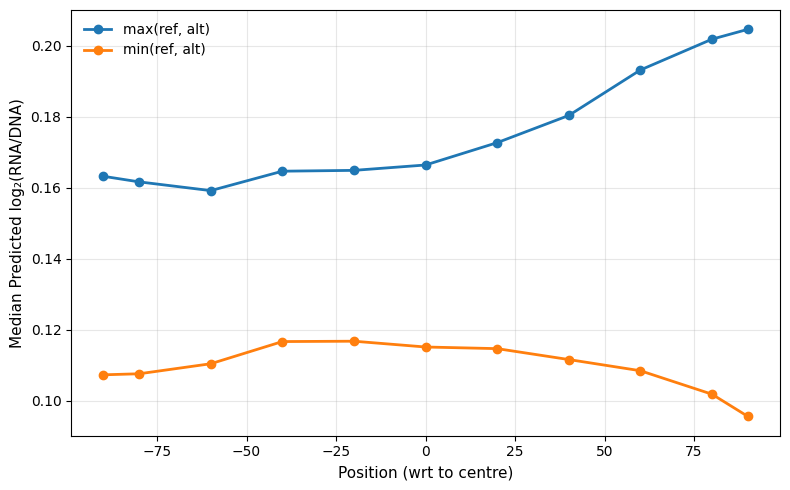

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Compute median profiles ---
median_max = max_df.median(axis=0)
median_min = min_df.median(axis=0)

# --- Extract numeric offsets (e.g., columns like 'offset_-90') ---
offsets = median_max.index.str.replace('offset_', '', regex=False).astype(int)

# --- Create plot ---
plt.figure(figsize=(8, 5))
plt.plot(offsets, median_max, marker='o', color='#1f77b4', lw=2, label='max(ref, alt)')
plt.plot(offsets, median_min, marker='o', color='#ff7f0e', lw=2, label='min(ref, alt)')

# --- Add style and annotations ---
# plt.axvline(0, color='red', linestyle='--', lw=1.2, label='Center (offset 0)')
# plt.title("Median Predicted Signal per Offset", fontsize=13, weight='bold')
plt.xlabel("Position (wrt to centre)", fontsize=11)
plt.ylabel("Median Predicted log₂(RNA/DNA)", fontsize=11)
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


